<a href="https://colab.research.google.com/github/ameydbharambe/Skin-Cancer-Detection/blob/main/SkinCancerDetectionCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image_dataset_from_directory
import gc

In [ ]:
# Download latest version
path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
Path to dataset files: /kaggle/input/skin-cancer-malignant-vs-benign


(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)


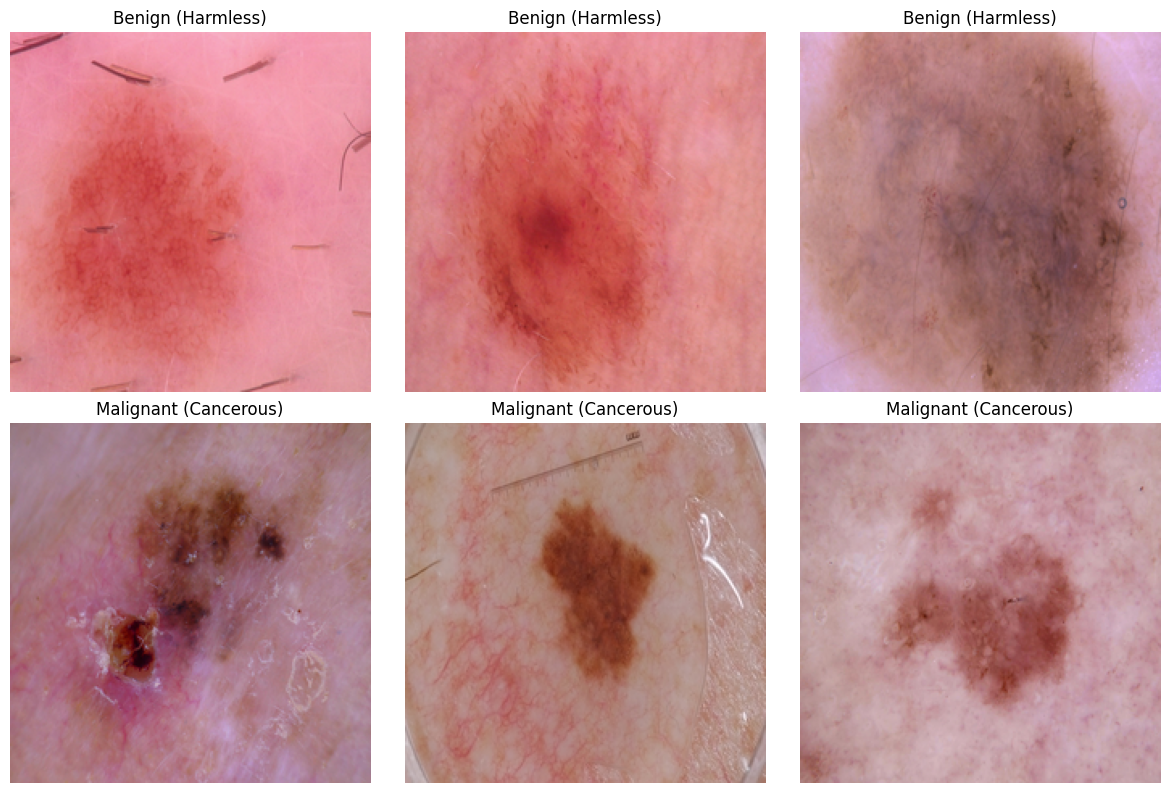

In [ ]:
benign_dir = os.path.join(path, "train/benign")
malignant_dir = os.path.join(path, "train/malignant")

# Grab 3 random images from each folder
benign_images = [os.path.join(benign_dir, f) for f in random.sample(os.listdir(benign_dir), 3)]
malignant_images = [os.path.join(malignant_dir, f) for f in random.sample(os.listdir(malignant_dir), 3)]

# Plot them out
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Show Benign
for i, img_path in enumerate(benign_images):
    img = Image.open(img_path)
    #image size
    print(img.size)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Benign (Harmless)")
    axes[0, i].axis('off')

# Show Malignant
for i, img_path in enumerate(malignant_images):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    print(img.size)
    axes[1, i].set_title("Malignant (Cancerous)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#We know size of images is 224 x 224. Most CNNs are fine with it, but for testing change to 384
size = 224
batch_size = 128

#Unload training and testing data
train_dir=os.path.join(path,'train')
test_dir=os.path.join(path,'test')

#Define datasets
train_ds = image_dataset_from_directory(
    train_dir,
    subset = 'training',
    color_mode = 'rgb',
    label_mode = 'binary',
    batch_size = batch_size,
    image_size = (size, size),
    shuffle = True,
    seed = 42,
    validation_split = 0.2,

)

valid_ds = image_dataset_from_directory(
    train_dir,
    subset = 'validation',
    color_mode = 'rgb',
    label_mode = 'binary',
    batch_size = batch_size,
    image_size = (size, size),
    shuffle = True,
    seed = 42,
    validation_split = 0.2,

)


test_ds=image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=(size, size),
    batch_size=batch_size
)



Found 2637 files belonging to 2 classes.
Using 2110 files for training.
Found 2637 files belonging to 2 classes.
Using 527 files for validation.
Found 660 files belonging to 2 classes.


In [ ]:
#Use data augmentation to create more training examples to help model understand variation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=42),
    layers.RandomRotation(0.1, seed=42),
    layers.RandomZoom(0.2, seed=42),
    layers.RandomBrightness(0.2, value_range=(0,255), seed=42)
])

#Apply augmentation
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

#Normalize datasets
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
valid_ds = valid_ds.map(lambda x, y: (x/255.0, y))
test_ds = test_ds.map(lambda x, y: (x/255.0, y))


In [ ]:
model = tf.keras.Sequential([
    # Convolutional Block 1

    layers.Conv2D(32, (3, 3), padding = 'same', activation = 'relu', input_shape=(size, size, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),


    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    # Flatten the output for the dense layers
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Optional: for regularization
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

#Define Loss Function
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

## **Reset Session**
To ensure optimal results run this code

In [ ]:


tf.keras.backend.clear_session()
gc.collect()

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

### **Callbacks for Training**

To optimize the training process and prevent overfitting, we'll use two important callbacks:

1.  **`EarlyStopping`**: This callback monitors a specified metric (e.g., `val_loss`) and stops training if the metric does not improve for a certain number of epochs (`patience`). This helps to prevent the model from overfitting to the training data.
2.  **`ReduceLROnPlateau`**: This callback reduces the learning rate when a metric (e.g., `val_loss`) has stopped improving. Reducing the learning rate can help the model converge to a better solution, especially when it's getting stuck in local minima.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=9,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

callbacks = [early_stop, reduce_lr]

epochs = 30 # Increased epochs since early stopping will halt it when performance plateaus

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5929 - loss: 1.0820 - val_accuracy: 0.7438 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7346 - loss: 0.5185 - val_accuracy: 0.6926 - val_loss: 0.5313 - learning_rate: 0.0010
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7479 - loss: 0.4920 - val_accuracy: 0.7932 - val_loss: 0.4654 - learning_rate: 0.0010
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7630 - loss: 0.4754 - val_accuracy: 0.7590 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7531 - loss: 0.5068 - val_accuracy: 0.7419 - val_loss: 0.5105 - learning_rate: 0.0010
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7735 - loss: 0.4736 - val_accuracy: 0.7856 - val_loss: 0.4432 - learning_rate: 0.0010
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7616 - loss: 0.4583 - val_accuracy: 

## **Plot Loss**

Though both curves are relativily bumpy, the loss function converges for validation and training loss over time to similar values with similar accuracy. So, though our accuracy is not necessary optimal, our accuracy on test data ranges in low 80s which is the human benchmark suggesting a good performance from our model

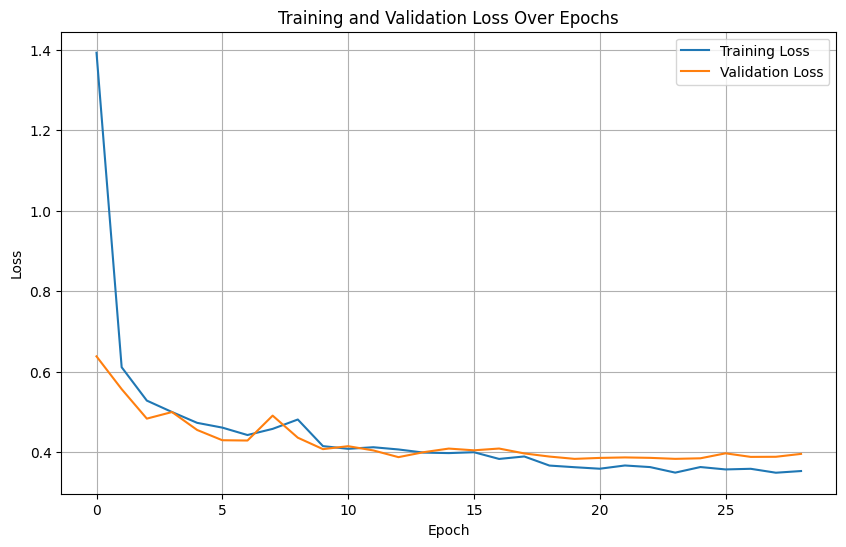

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show() #Need to make sure validation loss curve is more smooth

## **Test Data**

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Training Loss: {loss:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")

## **Make an API**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Save the trained model
model.save('skin_cancer_model.keras')
print("Model saved as 'skin_cancer_model.keras'")

# --- API Prediction Function ---
def predict_image_api(image_path, img_size=224):
    # Load the saved model (if not already loaded)
    # It's good practice to load the model once in your application and reuse it.
    # For demonstration, we'll load it here, but in a real API, load once.
    try:
        loaded_model = tf.keras.models.load_model('skin_cancer_model.keras')
    except Exception as e:
        return f"Error loading model: {e}"

    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = img_array / 255.0 # Normalize pixel values to [0, 1]

    # Make prediction
    predictions = loaded_model.predict(img_array)

    # Assuming binary classification with sigmoid output
    # The output is a single probability for the positive class (malignant in this case)
    malignant_probability = predictions[0][0]

    # You can return the probability or a class label
    # For example, classify as malignant if probability > 0.5
    class_label = "Malignant" if malignant_probability > 0.5 else "Benign"

    return {
        "prediction": class_label,
        "malignant_probability": float(malignant_probability) # Convert to float for JSON compatibility
    }

Model saved as 'skin_cancer_model.keras'
